# 05. Pseudobulks & reference signal

The [metacell AnnDatas](03_meta_cell_adata.ipynb) and the base-resolution
[parquet dataset](04_parquet_dataset.ipynb) describe **ChromiumPBMC** at metacell
resolution. A single metacell is still shallow, though — Bolero conditions on and is
evaluated against **pseudobulks**: small groups of nearby metacells merged to a fixed
sequencing depth. This page builds those units, plus one whole-dataset bulk track:

1. **Coverage-matched pseudobulks** — within each cell-type group, merge nearby metacells
   until each pseudobulk holds ~5M fragments. Every pseudobulk carries a representative
   embedding, a coverage-scale factor, and a sampling weight — the record the training and
   inference data loaders consume.
2. **Inference selection** — flag a small, metadata-balanced subset of those pseudobulks so
   metadata-driven inference runs the fewest pseudobulks for the most cell-type diversity.
3. **Reference signal** — merge a sample of metacells into a single whole-dataset bulk and
   write it to a **BigWig** track for genome-browser visualization and as a reference in
   variant / differential comparisons.

> **Where the data comes from.** This notebook runs in place on the artifacts built earlier
> in this section: the per-cell `adata.multivi.with_coords.h5ad` (from
> [cell embedding](../embedding_and_meta_cell/01_cell_embedding.ipynb)), the metacell
> `metacell.metadata.h5ad` (from [page 03](03_meta_cell_adata.ipynb)), and the
> `ChromiumPBMC-MetaCell-32bp/` parquet store (from [page 04](04_parquet_dataset.ipynb)).
> The genome (`hg38`) is resolved from the companion registry
> [`bolerodata`](https://github.com/liuhlab/bolerodata).

## Setup

In [1]:
import logging
from pathlib import Path
from warnings import simplefilter

import anndata
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyBigWig
import seaborn as sns
import SEACells

from bolero import init
from bolero.tl.pseudobulk import prepare_multi_level_categorical_groups
from bolero.tl.pseudobulk.paired_pseudobulk import EnsemblePairedPseudobulker
from bolero.tl.dataset.parquet_db import GenomeParquetDB
from bolerodata import DATASETS

simplefilter("ignore")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]  # a font that ships with the env
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

init(num_cpus=8)  # Ray backs the parquet reads used to build the reference BigWig

2026-07-13 10:27:43,012	INFO worker.py:1781 -- Started a local Ray instance.


In [2]:
# --- Configuration ---------------------------------------------------------------
DATASET_NAME = "ChromiumPBMC"
EMB_KEY = "X_multivi"  # per-cell embedding produced by 01_cell_embedding (MULTIVI)

INPUT_ADATA = "adata.multivi.with_coords.h5ad"  # per-cell, carries obs["meta_cell"]
METADATA_H5AD = "metacell.metadata.h5ad"  # metacell-level table (from page 03)
PARQUET_DIR = f"{DATASET_NAME}-MetaCell-32bp"  # base-resolution store (from page 04)
PREFIX = f"{DATASET_NAME}.MetaCell"  # matches the parquet row-name prefix

TARGET_COV = 5_000_000  # target fragments per pseudobulk
EMB_PAD_TO_SIZE = 128  # cap on metacells pooled per pseudobulk

# outputs
PSEUDOBULK_JOBLIB = f"pseudobulk_records_and_cond.cov{TARGET_COV}.joblib"
REFERENCE_PB_JOBLIB = "reference_pseudobulk.joblib"
REFERENCE_BW = "reference.bw"

dataset = DATASETS[DATASET_NAME]

# the metadata columns that define a "cell-type group"; ChromiumPBMC groups by subclass
GROUPBY_COLS = dataset.metadata["fine_grouping"].split("+")
print("groupby cols:", GROUPBY_COLS)

groupby cols: ['subclass']


## Part 1 — Coverage-matched pseudobulks

A pseudobulk pools nearby metacells until it reaches a target depth (`TARGET_COV`, 5M
fragments). We build them **within cell-type groups** so a pseudobulk never mixes distinct
cell types. The recipe is: (1) split cells into groups by metadata + embedding, (2) within
each group, use SEACells to pick spread-out **archetype** metacells and grow a coverage-matched
neighborhood around each, (3) record every pseudobulk's metacell membership, embedding, and
coverage scale.

### Step 1.1 — Group cells by metadata + embedding

`prepare_multi_level_categorical_groups` walks the `GROUPBY_COLS` in priority order, and — for
any category too large to stay a single group — subdivides it by hierarchical clustering on the
cell embedding, stopping when a subgroup would fall below `min_cell_count`. `min_cell_count` is
set so a group is only split if the pieces can still reach the target coverage.

> The lab pipeline additionally passes `hard_group_cols=["TrainTest"]` to keep train/test cells
> in separate groups. ChromiumPBMC carries no such split, so we omit it here.

In [3]:
adata = anndata.read_h5ad(INPUT_ADATA)  # per-cell
cell_meta = adata.obs
cell_emb = pd.DataFrame(adata.obsm[EMB_KEY], index=adata.obs_names)

meta_adata = anndata.read_h5ad(METADATA_H5AD)  # metacell-level (from page 03)

# only split a group if the resulting pieces can still hit the coverage target
min_cell_count = max(500, int(TARGET_COV / cell_meta["n_fragments"].mean() * 1.25))
print("min_cell_count:", min_cell_count)

cell_to_group, group_to_cats = prepare_multi_level_categorical_groups(
    cell_meta,
    embedding=cell_emb,
    group_cols=GROUPBY_COLS,
    min_cell_count=min_cell_count,
)
print(f"{len(group_to_cats)} cell-type groups")

min_cell_count: 500
Cell metadata has 45270 cells
Cell embedding has 45270 cells
Intersection index has 45270 cells
9 cell-type groups


### Step 1.2 — Carry the group onto each metacell

Each metacell inherits the majority group of its cells. We also check that the metacell set
matches the parquet dataset's row order from [page 04](04_parquet_dataset.ipynb) — the pseudobulk
records reference metacells **by name**, so the two must agree.

In [4]:
most_frequent = lambda s: s.dropna().value_counts().index[0]

adata.obs["meta_group"] = cell_to_group
meta_cell_to_group = adata.obs.groupby("meta_cell", observed=True)["meta_group"].agg(
    most_frequent
)
meta_adata.obs["groupby"] = meta_adata.obs_names.map(meta_cell_to_group)

# metacells must line up with the parquet rows built in page 04
row_names = joblib.load(Path(PARQUET_DIR) / "row_names.joblib")[PREFIX]
assert set(row_names) == set(meta_adata.obs_names), "metacell set != parquet rows"
print(f"{meta_adata.n_obs} metacells, consistent with the 32 bp parquet")
meta_adata.obs["groupby"].value_counts()

619 metacells, consistent with the 32 bp parquet


groupby
group8    229
group5    188
group2     47
group3     47
group7     44
group1     26
group6     20
group4     11
group0      7
Name: count, dtype: int64

### Step 1.3 — Merge metacells into coverage-matched pseudobulks

Within each group we estimate how many pseudobulks fit (`group coverage / TARGET_COV`) and ask
SEACells for that many **archetypes** — metacells spread across the group's embedding. For each
archetype we walk out to its nearest neighbors (in the SEACells kernel) and stop once their
summed coverage reaches `TARGET_COV`, capped at `EMB_PAD_TO_SIZE` metacells. Tiny groups become a
single pseudobulk; small groups pick archetypes at random instead of fitting the full model.

In [5]:
all_pseudobulks = {}
for group, group_df in meta_adata.obs.groupby("groupby", observed=True):
    group_adata = meta_adata[group_df.index].copy()
    group_size = TARGET_COV / group_adata.obs["n_fragments"].mean()
    n_meta_cells = int(np.ceil(group_adata.shape[0] / group_size)) * 2
    n_meta_cells = min(group_adata.shape[0], n_meta_cells)

    if n_meta_cells <= 2:
        all_pseudobulks[f"{group}-pseudobulk0"] = group_adata.obs_names.tolist()
        continue

    model = SEACells.core.SEACells(
        group_adata,
        build_kernel_on="X_emb",
        n_SEACells=n_meta_cells,
        n_neighbors=min(max(15, int(group_size) + 5), group_adata.shape[0] - 1),
        n_waypoint_eigs=min(10, n_meta_cells - 1),
        convergence_epsilon=1e-5,
        verbose=False,
    )
    model.construct_kernel_matrix()

    if (n_meta_cells < 10) | (group_adata.shape[0] < 20):
        # too small to fit -- pick archetypes at random
        archetypes = group_adata.obs.sample(n_meta_cells, replace=False).index
    else:
        model.initialize_archetypes()
        try:
            model.fit(min_iter=10, max_iter=100)
        except RuntimeWarning:
            pass
        archetypes = model.get_hard_archetypes()

    # grow each archetype's neighborhood until it reaches TARGET_COV coverage
    kernel_adata = anndata.AnnData(
        model.kernel_matrix, obs=group_adata.obs, var=group_adata.obs
    )
    arche_kernel_adata = kernel_adata[archetypes].copy()
    for idx, row in enumerate(arche_kernel_adata.X):
        nn_dist = pd.Series(
            row.data, index=arche_kernel_adata.var_names[row.indices]
        ).sort_values(ascending=False)
        nn_cov_cumsum = (
            arche_kernel_adata.var.loc[nn_dist.index, "n_fragments"]
            .astype(float)
            .cumsum()
        )
        use_nns = (nn_cov_cumsum - TARGET_COV).abs().argmin() + 1
        final_list = nn_dist.index[:use_nns].tolist()[:EMB_PAD_TO_SIZE]
        all_pseudobulks[f"{group}-pseudobulk{idx}"] = final_list

print(
    f"{len(all_pseudobulks)} pseudobulks across {meta_adata.obs['groupby'].nunique()} groups"
)

Welcome to SEACells!


  0%|          | 0/7 [00:00<?, ?it/s]

Parameter graph_construction = union being used to build KNN graph...


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

...

  0%|          | 0/229 [00:00<?, ?it/s]

Building kernel on X_emb


  0%|          | 0/41 [00:00<?, ?it/s]

100%|██████████| 41/41 [00:00<00:00, 1128.06it/s]

327 pseudobulks across 9 groups


### Step 1.4 — Assemble the pseudobulk records

Each pseudobulk becomes a record the data loader understands. `cluster_ids` lists its metacells
(keyed by `PREFIX` so it maps onto the parquet rows); `cov_scale` is the log2 depth relative to
target; `embedding` is the archetype's representative cell-state vector. A per-group
`sample_weight` up-weights rare cell types so they are sampled as often as common ones during
training.

In [6]:
pseudobulk_records = {}
for key, meta_cell_list in all_pseudobulks.items():
    archetype = meta_cell_list[0]
    n_frags = meta_adata.obs.loc[meta_cell_list, "n_fragments"].sum()
    pseudobulk_records[key] = {
        "cluster_ids": {PREFIX: meta_cell_list},
        "n_frags": {PREFIX: n_frags},
        "cov_scale": {PREFIX: np.log2(n_frags / TARGET_COV)},
        "embedding": meta_adata[archetype].obsm["X_emb"].copy().ravel(),
    }

# up-weight rare groups: weight ~ 1/sqrt(group size), normalized to sum to 1
group_sample_weight = 1 / np.sqrt(meta_adata.obs["groupby"].value_counts())
group_sample_weight /= group_sample_weight.sum()
for key, record in pseudobulk_records.items():
    record["sample_weight"] = group_sample_weight[key.split("-")[0]]

print(len(pseudobulk_records), "pseudobulk records")

327 pseudobulk records


### Step 1.5 — Conditions (none for ChromiumPBMC)

Some datasets attach extra **conditioning variables** to pseudobulks — tissue, developmental age,
or an AP-1 activity score (the paper's *Bolero-Score*). ChromiumPBMC uses none, so these
containers stay empty; the field is kept so the saved file matches the schema the pseudobulker
expects.

In [7]:
condition_to_related_pseudobulk = {}
condition_terms = {}
condition_emb = {}

pseudobulk_info = {
    "pseudobulk_records": pseudobulk_records,
    "meta_cell_emb": pd.DataFrame(meta_adata.obsm["X_emb"], index=meta_adata.obs_names),
    "meta_cell_n_frags": meta_adata.obs["n_fragments"],
    "target_cov": TARGET_COV,
    "condition_to_related_pseudobulk": condition_to_related_pseudobulk,
    "condition_emb": condition_emb,
    "condition_terms": condition_terms,
}
joblib.dump(pseudobulk_info, PSEUDOBULK_JOBLIB)
print("wrote", PSEUDOBULK_JOBLIB)

wrote pseudobulk_records_and_cond.cov5000000.joblib


### Check — coverage per pseudobulk

The merge targets 5M fragments, so the per-pseudobulk depth should cluster around `TARGET_COV`
(the spread comes from the discrete metacell sizes and the `EMB_PAD_TO_SIZE` cap).

median depth: 4,969,121 fragments


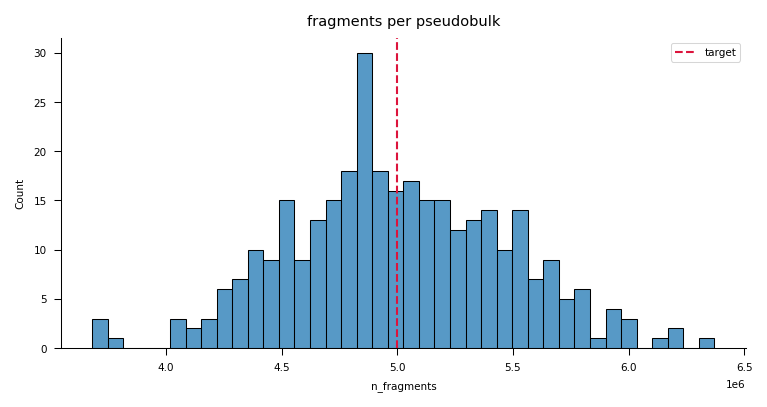

In [8]:
pid_frags = pd.Series({k: v["n_frags"][PREFIX] for k, v in pseudobulk_records.items()})

fig, ax = plt.subplots(figsize=(5, 2.6), dpi=150, constrained_layout=True)
sns.histplot(pid_frags, bins=40, ax=ax)
ax.axvline(TARGET_COV, color="crimson", ls="--", lw=1, label="target")
ax.set(title="fragments per pseudobulk", xlabel="n_fragments")
ax.legend()
print(f"median depth: {pid_frags.median():,.0f} fragments")

### Check — pseudobulks are embedding-coherent

Because each pseudobulk is grown from a single archetype's neighborhood, its metacells should
occupy one tight region of the embedding. Highlighting a few pseudobulks' member cells on the
UMAP confirms they are spatially coherent rather than scattered across cell types.

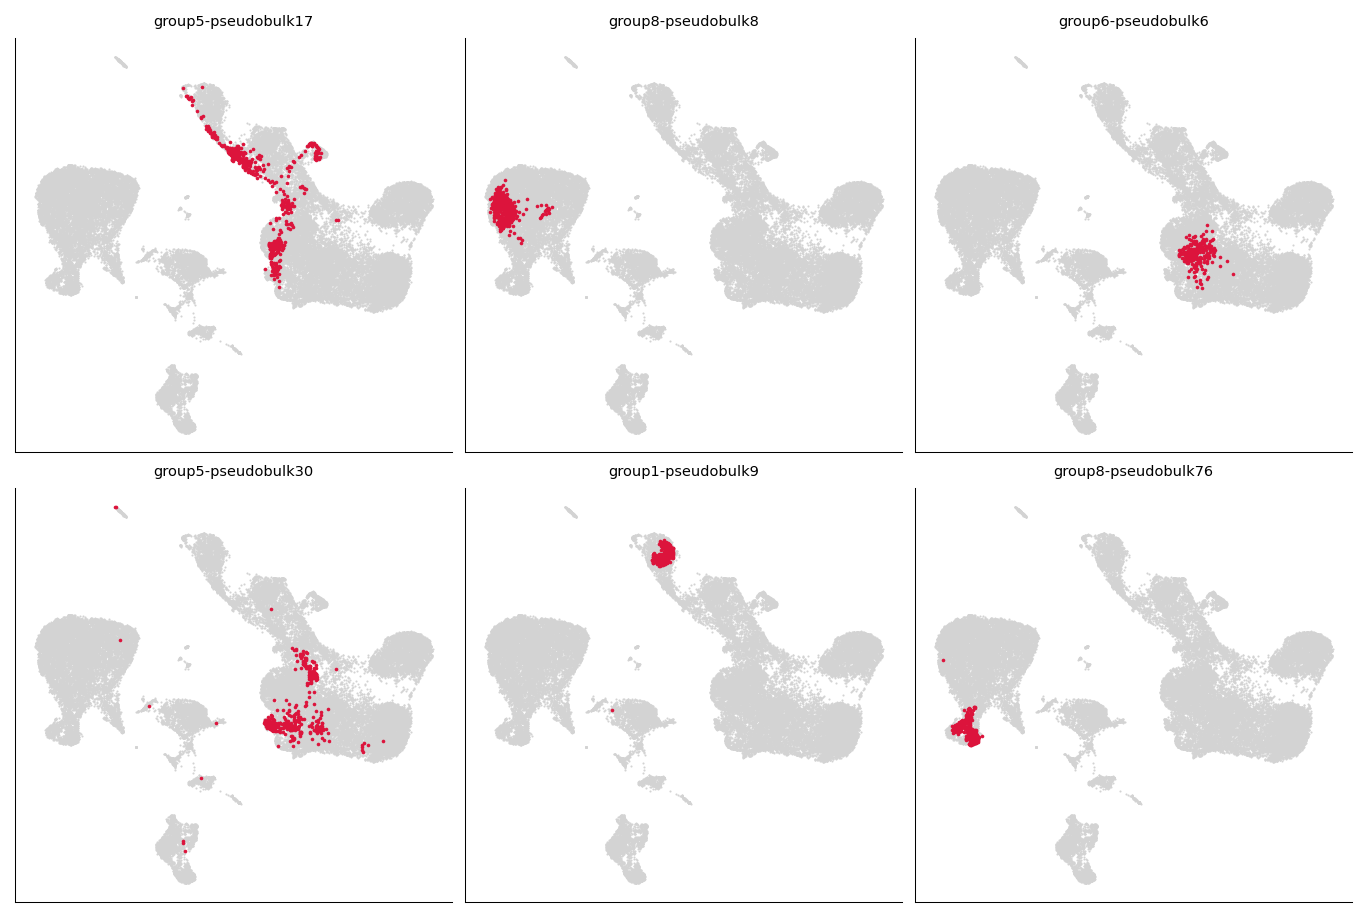

In [9]:
umap = adata.obsm["X_umap"]
keys = list(all_pseudobulks)
sel_keys = np.random.default_rng(0).choice(keys, min(6, len(keys)), replace=False)

fig, axes = plt.subplots(
    figsize=(9, 6), ncols=3, nrows=2, dpi=150, constrained_layout=True
)
for ax, key in zip(axes.ravel(), sel_keys, strict=False):
    ax.scatter(umap[:, 0], umap[:, 1], s=1, c="lightgrey", lw=0)
    member = adata.obs["meta_cell"].isin(all_pseudobulks[key]).values
    ax.scatter(umap[member, 0], umap[member, 1], s=3, c="crimson", lw=0)
    ax.set(title=key, xticks=[], yticks=[])

### Check — the pseudobulker reads the records

`EnsemblePairedPseudobulker` is the sampler the training/inference loaders wrap around this file.
Each draw is a **pair** `(p0, p1)`: `p1` is one of our coverage-matched pseudobulks (a specific
cell state, picked by name), while `p0` is an on-the-fly *ensemble background* — the mean of many
metacells sampled across the whole dataset. It concatenates their embeddings (30 + 30 → 60) into
`__embedding__`, the reference→target pair behind Bolero's delta/velocity head, alongside
`cov_scale`, `__covlogfc__`, and a condition embedding `__conditionemb__` (width 0 here, since
ChromiumPBMC has no conditions). Loading cleanly confirms the records are well-formed.

In [ ]:
pseudobulker = EnsemblePairedPseudobulker(PSEUDOBULK_JOBLIB)
p0, p1 = next(iter(pseudobulker.take(1)))

print("batch fields:")
for k, v in p1.items():
    print(f"  {k:20s} {getattr(v, 'shape', type(v).__name__)}")
print("condition embedding dims:", dict(pseudobulker.condition_encoder.cond_emb_dims))

## Part 2 — Select pseudobulks for inference

Training samples all pseudobulks, but for a metadata-driven inference sweep we want the fewest
pseudobulks that still cover the cell-type diversity. We annotate each pseudobulk with the
dominant subclass of its metacells, then keep up to `N_PSEUDOBULK_PER_CATEGORY` per subclass —
flagging them in an `Inference` column stored back into the same file.

In [11]:
N_PSEUDOBULK_PER_CATEGORY = 2
ANNOT_COLS = ["subclass"]

# dominant subclass of each pseudobulk, from the metacells it pools
pid_annot = {}
for pid, rec in pseudobulk_records.items():
    cids = rec["cluster_ids"][PREFIX]
    pid_annot[pid] = {
        col: meta_adata.obs.loc[cids, col].value_counts().index[0] for col in ANNOT_COLS
    }
pid_annot = pd.DataFrame(pid_annot).T

# keep up to N pseudobulks per category for a compact, diverse inference set
all_sels = [
    cond_df.sample(min(N_PSEUDOBULK_PER_CATEGORY, cond_df.shape[0]), random_state=42)
    for _, cond_df in pid_annot.groupby(ANNOT_COLS, observed=True)
]
all_sels = pd.concat(all_sels)
pid_annot["Inference"] = pid_annot.index.isin(all_sels.index)

print(
    f"{pid_annot.shape[0]} pseudobulks -> {int(pid_annot['Inference'].sum())} for inference"
)

pseudobulk_info["pseudobulk_annot"] = pid_annot
joblib.dump(pseudobulk_info, PSEUDOBULK_JOBLIB)
pid_annot.head()

327 pseudobulks -> 30 for inference


,subclass,Inference
group0-pseudobulk0,MAIT_cells,False
group0-pseudobulk1,MAIT_cells,True
group0-pseudobulk2,MAIT_cells,False
group0-pseudobulk3,MAIT_cells,True
group1-pseudobulk0,CD16__NK_cells,False


## Part 3 — Whole-dataset reference signal

Finally we collapse the dataset to a single **bulk** track: sample up to `MAX_REF_META_CELLS` of
the metacells used in the pseudobulks, merge their base-resolution coverage, normalize to the
target depth, and write a BigWig. This reference track is convenient for genome-browser
visualization and serves as a baseline in variant / differential comparisons.

### Step 3.1 — Sample metacells and record the reference pseudobulk

In [12]:
MAX_REF_META_CELLS = 1000

# every metacell that participates in a pseudobulk, then a capped random sample
ref_meta_cells = sorted(
    {mc for rec in pseudobulk_records.values() for mc in rec["cluster_ids"][PREFIX]}
)
rng = np.random.default_rng(seed=42)
n_ref = min(MAX_REF_META_CELLS, len(ref_meta_cells))
ref_meta_cells = list(rng.choice(ref_meta_cells, n_ref, replace=False))

n_frags = meta_adata.obs.loc[ref_meta_cells, "n_fragments"].sum()
count_norm = TARGET_COV / n_frags  # rescale the merged bulk to TARGET_COV depth
ref_pseudobulk = {
    "cluster_ids": {PREFIX: ref_meta_cells},
    "n_frags": {PREFIX: n_frags},
    "cov_scale": {PREFIX: np.log2(n_frags / TARGET_COV)},
    "embedding": meta_adata[ref_meta_cells].obsm["X_emb"].mean(axis=0),
}
joblib.dump(ref_pseudobulk, REFERENCE_PB_JOBLIB)
print(
    f"{len(ref_meta_cells)} metacells, {n_frags:,.0f} fragments -> normalize x{count_norm:.3f}"
)

598 metacells, 781,080,128 fragments -> normalize x0.006


### Step 3.2 — Merge coverage and write the BigWig

A `merge_plan` tells `GenomeParquetDB` to sum the sampled metacells into a **single** pseudobulk
row named `reference`. We then walk the genome in 500 kb windows, pull each window's merged
coverage, scale it by `count_norm`, and append the nonzero bins to the BigWig at the dataset's
32 bp resolution.

In [13]:
def write_pseudobulk_bigwig(parquet_db, genome, output_path, count_norm):
    """Write the merged (single-row) pseudobulk coverage to a BigWig track."""
    genome_window = genome.make_windows(500_000, 500_000, as_df=False)
    region_lookup_bed = parquet_db.region_lookup_bed.merge()
    genome_window = genome_window.overlap(region_lookup_bed, how="containment").df
    genome_window["Name"] = genome_window.index

    output_path = Path(output_path)
    temp_path = Path(f"{output_path}.tmp")
    bigwig = pyBigWig.open(str(temp_path), "w")
    bigwig.addHeader(list(genome.chrom_sizes.items()))

    chunk_size = 1000
    prefix_name = parquet_db.prefix_names[0]  # the single merged "reference" row
    resolution = parquet_db.prefix_resolution[prefix_name]
    for chrom in genome.chrom_sizes.index:
        print(f"writing {chrom}")
        chrom_window = genome_window.query(f"Chromosome == '{chrom}'")
        for chunk_start in range(0, chrom_window.shape[0], chunk_size):
            chunk_window = chrom_window.iloc[chunk_start : chunk_start + chunk_size]
            chunk_data = parquet_db.query_regions(chunk_window)
            chunk_data = {d["region"]: d[prefix_name].todense().A1 for d in chunk_data}
            chunk_data = (
                np.concatenate(
                    [chunk_data[name] for name in chunk_window["Name"].values]
                )
                * count_norm
            )
            starts = np.where(chunk_data)[0]
            values = chunk_data[starts]
            starts *= resolution
            bigwig.addEntries(chrom, starts, values=values, span=resolution)
    bigwig.close()

    if output_path.exists():
        output_path.unlink()
    temp_path.rename(output_path)

In [14]:
parquet_db = GenomeParquetDB(
    dataset_dir=PARQUET_DIR, parallel=8, merge_plan={"reference": ref_meta_cells}
)
write_pseudobulk_bigwig(parquet_db, dataset.Genome, REFERENCE_BW, count_norm)
print("wrote", REFERENCE_BW)

writing chr1


writing chr10


writing chr11


writing chr12


writing chr13


...

writing chr8


writing chr9


writing chrM
writing chrX


writing chrY


wrote reference.bw


### Check — read the reference track back

Reopen the BigWig and plot the normalized coverage over the **ACTB** promoter (chr7 ~5.53 Mb), a
housekeeping locus that is strongly accessible in nearly every cell type — a quick confirmation
the merged bulk carries signal where it should.

header: {'version': 4, 'nLevels': 8, 'nBasesCovered': 2301409504, 'minVal': 0, 'maxVal': 326, 'sumData': 318412222, 'sumSquared': 3695893763}


[Text(0.5, 1.0, 'reference bulk — chr7:5525000-5535000 (ACTB)'),
 Text(0.5, 0, 'genomic position'),
 Text(0, 0.5, 'norm. coverage')]

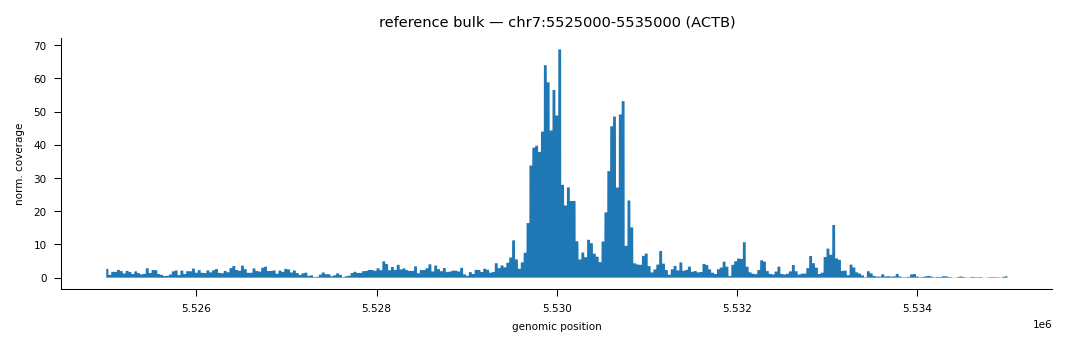

In [15]:
region = "chr7:5525000-5535000"  # ACTB promoter (hg38), broadly accessible
chrom, span = region.split(":")
start, end = (int(x) for x in span.split("-"))

bw = pyBigWig.open(REFERENCE_BW)
print("header:", bw.header())
track = np.nan_to_num(np.asarray(bw.values(chrom, start, end)))
bw.close()

fig, ax = plt.subplots(figsize=(7, 2.2), dpi=150, constrained_layout=True)
ax.fill_between(np.arange(start, end), track, lw=0)
ax.set(
    title=f"reference bulk — {region} (ACTB)",
    xlabel="genomic position",
    ylabel="norm. coverage",
)

---

For **ChromiumPBMC** you now have the conditioned units Bolero trains and predicts on:
`pseudobulk_records_and_cond.cov5000000.joblib` (coverage-matched pseudobulks with embeddings,
coverage scales, sampling weights, and an inference flag), `reference_pseudobulk.joblib`, and the
whole-dataset `reference.bw` track. Together with the metacell AnnDatas and the 32 bp parquet
store, this completes the data a single dataset contributes to the Bolero-10M training corpus.